In [17]:
# Install des packages 
install.packages(c("tidyverse", "FactoMineR", "factoextra", "corrplot", "caret", "randomForest", "lmtest", "car", "ggrepel", "scales", "viridis", "outliers", "glmnet", "dplyr", "rlang"))

Installation du package dans ‘/home/ymokhtar/R/x86_64-pc-linux-gnu-library/4.3’
(car ‘lib’ n'est pas spécifié)



In [18]:

library(tidyverse)
library(FactoMineR)
library(factoextra)
library(corrplot)
library(caret)
library(randomForest)
library(lmtest)
library(car)
library(ggrepel)
library(scales)
library(viridis)
library(outliers)
library(glmnet)
library(dplyr)
library(corrplot)

# Quels sont les facteurs associés au succès commercial d'un jeu ?

## Définir le succès commercial

In [2]:
df <- read_csv("clean.csv")

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 113121 Columns: 37
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (10): Name, Release date, Estimated owners, Supported languages, Full au...
dbl (23): AppID, Peak CCU, Required age, Price, Discount, DLC count, Reviews...
lgl  (4): Windows, Mac, Linux, Score rank

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 113,121
Columns: 37
$ AppID                        <dbl> 730, 570, 578080, 3419430, 2622380, 25249…
$ Name                         <chr> "Counter-Strike 2", "Dota 2", "PUBG: BATT…
$ `Release date`               <chr> "Aug 21, 2012", "Jul 9, 2013", "Dec 21, 2…
$ `Estimated owners`           <chr> "100000000 - 200000000", "100000000 - 200…
$ `Peak CCU`                   <dbl> 1013936, 623941, 314682, 164168, 163599, …
$ `Required age`               <dbl> 0, 0, 13, 0, 17, 0, 0, 0, 0, 0, 17, 17, 0…
$ Price                        <dbl> 0.00, 0.00, 0.00, 0.00, 29.99, 19.99, 0.0…
$ Discount                     <dbl> 0, 0, 0, 0, 25, 50, 0, 0, 20, 20, 0, 45, …
$ `DLC count`                  <dbl> 1, 2, 0, 0, 1, 5, 0, 0, 1, 1, 0, 43, 4, 2…
$ `Supported languages`        <chr> "['Czech', 'Danish', 'Dutch', 'English', …
$ `Full audio languages`       <chr> "['English', 'Indonesian']", "['English',…
$ Reviews                      <dbl> 0, 4, 0, 0, 0, 1, 4, 3, 0, 0, 0, 0, 4, 0,…
$ Windows     

[1] "AppID"                      "Name"                      
 [3] "Release date"               "Estimated owners"          
 [5] "Peak CCU"                   "Required age"              
 [7] "Price"                      "Discount"                  
 [9] "DLC count"                  "Supported languages"       
[11] "Full audio languages"       "Reviews"                   
[13] "Windows"                    "Mac"                       
[15] "Linux"                      "Metacritic score"          
[17] "User score"                 "Positive"                  
[19] "Score rank"                 "Achievements"              
[21] "Recommendations"            "Average playtime forever"  
[23] "Average playtime two weeks" "Median playtime forever"   
[25] "Median playtime two weeks"  "Developers"                
[27] "Publishers"                 "Categories"                
[29] "Genres"                     "Tags"                      
[31] "has_header image"           "has_screenshots"           
[33] "has_website"                "has_support url"           
[35] "has_support email"          "has_about the game"        
[37] "Ratio positive vote"

[1] 113121     37

AppID                       Name 
                         0                          0 
              Release date           Estimated owners 
                         0                          0 
                  Peak CCU               Required age 
                         0                          0 
                     Price                   Discount 
                         0                          0 
                 DLC count        Supported languages 
                         0                          0 
      Full audio languages                    Reviews 
                         0                          0 
                   Windows                        Mac 
                         0                          0 
                     Linux           Metacritic score 
                         0                          0 
                User score                   Positive 
                         0                          0 
                Score rank               Achievements 
                    113121                          0 
           Recommendations   Average playtime forever 
                         0                          0 
Average playtime two weeks    Median playtime forever 
                         0                          0 
 Median playtime two weeks                 Developers 
                         0                        149 
                Publishers                 Categories 
                       617                          0 
                    Genres                       Tags 
                         0                          0 
          has_header image            has_screenshots 
                         0                          0 
               has_website            has_support url 
                         0                          0 
         has_support email         has_about the game 
                         0                          0 
       Ratio positive vote 
                     31085

### Transformations des features du dataset pour préparer notre variable success_score

In [36]:
df_clean <- df %>%

  select(-`Score rank`, -`User score`) %>%
  
  
  mutate(
    total_reviews = ifelse(`Ratio positive vote` > 0 & !is.na(`Ratio positive vote`),
                           round(Positive / `Ratio positive vote`),
                           Positive),  # si ratio NA, on a 0 négatifs
    Negative = total_reviews - Positive
  ) %>%
  
  # mediane des owners pour tout le monde
  mutate(
    owners_low  = as.numeric(str_extract(`Estimated owners`, "^[0-9]+")),
    owners_high = as.numeric(str_extract(`Estimated owners`, "[0-9]+$")),
    owners_midpoint = (owners_low + owners_high) / 2
  ) %>%
  
  
  mutate(
    nb_languages = str_count(`Supported languages`, ",") + 1
  ) %>%
  
  
  mutate(
    log_owners          = log1p(owners_midpoint),
    log_recommendations = log1p(Recommendations),
    log_peak_ccu        = log1p(`Peak CCU`),
    log_median_playtime = log1p(`Median playtime forever`)
  )

### Évaluation de la fiabilité des ratings avec le Wilson Score

In [37]:
wilson_score <- function(positive, negative, z = 1.96) {
  n <- positive + negative
  if (n == 0) return(NA)
  p_hat <- positive / n
  numerator   <- p_hat + z^2/(2*n) - z * sqrt(p_hat*(1-p_hat)/n + z^2/(4*n^2))
  denominator <- 1 + z^2/n
  return(numerator / denominator)
}

df_clean <- df_clean %>%
  mutate(
    wilson = mapply(wilson_score, Positive, Negative)
  )

### Création de la variable sucess_score

In [38]:
df_clean <- df_clean %>%
  mutate(
    success_score = 0.5 * log_owners +
                    0.3 * log_recommendations +
                    0.2 * wilson
  )

Visualisation de la distribution du score de succès commercial selon les jeux

Warning message:
“Removed 33644 rows containing non-finite outside the scale range
(`stat_bin()`).”


[1] 1493

Name,success_score,log_owners,log_recommendations,wilson
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Counter-Strike 2,14.20355,18.82615,15.39045,0.8667080
PUBG: BATTLEGROUNDS,13.84493,18.82615,14.37699,0.5938040
Grand Theft Auto V Legacy,13.57113,18.13300,14.43300,0.8736560
Black Myth: Wukong,13.36022,18.13300,13.66820,0.9663009
Left 4 Dead 2,13.32811,18.13300,13.55535,0.9750388
Palworld,13.07861,18.13300,12.74684,0.9402968
Terraria,13.07030,17.37086,13.96652,0.9745576
Tom Clancy's Rainbow Six® Siege X,13.05828,17.37086,14.01752,0.8379904
Call of Duty®,13.05575,18.13300,12.90656,0.5864306


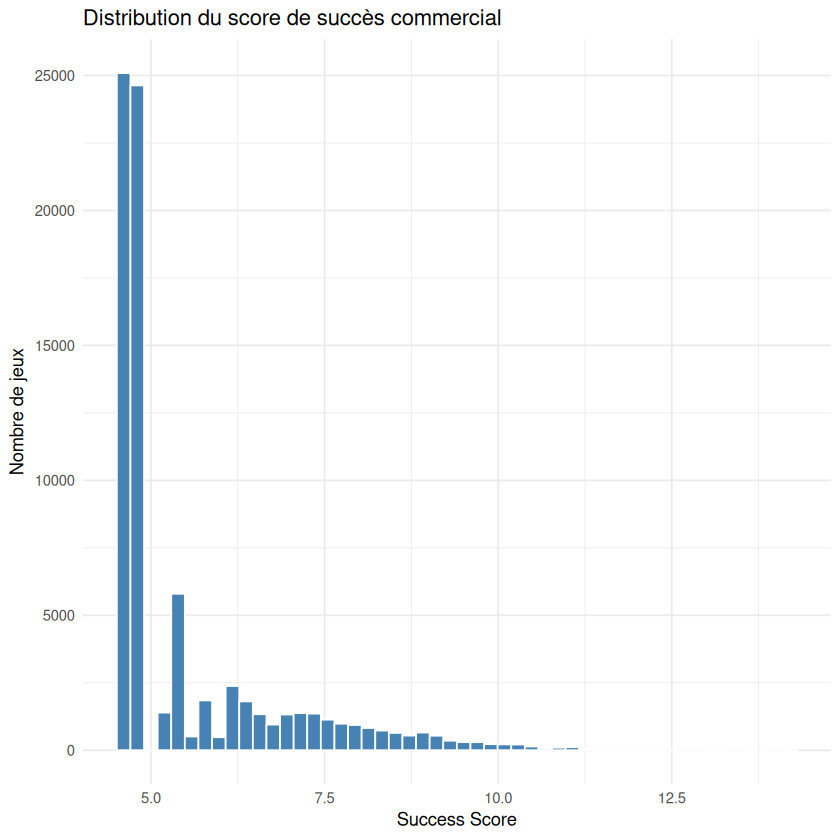

In [39]:
ggplot(df_clean, aes(x = success_score)) +
  geom_histogram(bins = 50, fill = "steelblue", color = "white") +
  labs(title = "Distribution du score de succès commercial",
       x = "Success Score", y = "Nombre de jeux") +
  theme_minimal()

# idd les outliers 
df_clean <- df_clean %>%
  mutate(
    success_zscore = scale(success_score)[,1],
    is_outlier = abs(success_zscore) > 3
  )

# combien d'outliers 
sum(df_clean$is_outlier, na.rm = TRUE)

df_clean %>%
  filter(is_outlier) %>%
  select(Name, success_score, log_owners, log_recommendations, wilson) %>%
  arrange(desc(success_score)) %>%
  head(20)


Score pour OuterWilds par exemple (très bon bien que indie game) 

In [40]:

df_clean %>%
  filter(str_detect(Name, "Outer Wilds")) %>%
  select(Name, success_score, log_owners, log_recommendations, 
         wilson, owners_midpoint, Positive, Negative)

Name,success_score,log_owners,log_recommendations,wilson,owners_midpoint,Positive,Negative
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Outer Wilds,10.68294,14.22098,11.27126,0.9553467,1500000,80833,3655


# Quels facteurs sont associés au succès commercial
### Visualisation des corrélations entre variables avec un corrplot afin pour avoir une première idée des relations avec le succès commercial.

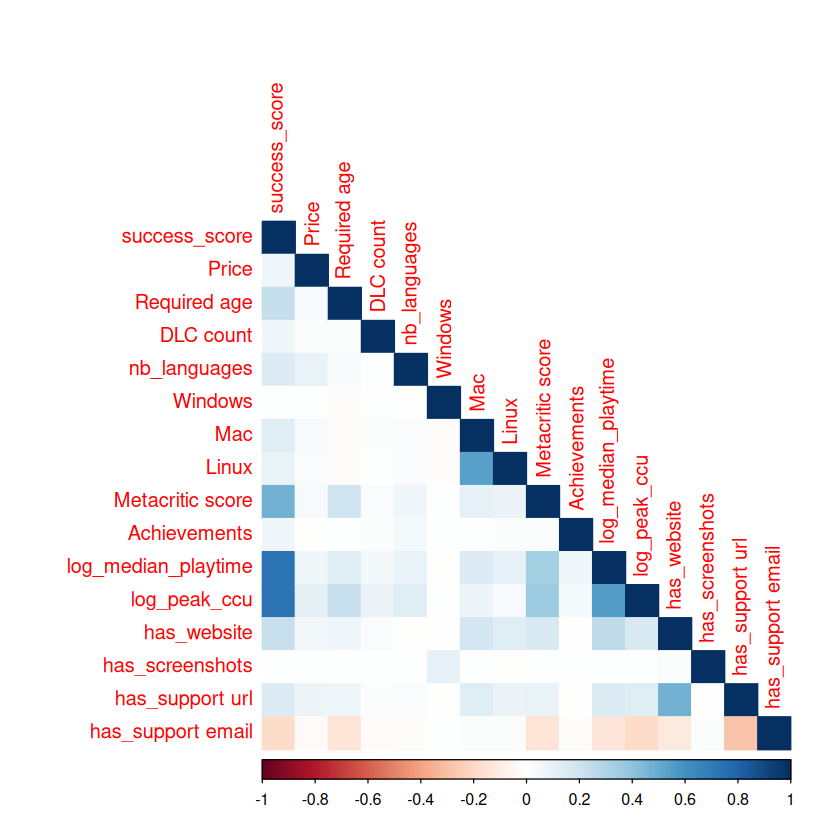

In [41]:
cor_matrix <- cor(data_model)
corrplot(cor_matrix, method = "color", type = "lower")

### Modèle LASSO plus robuste pour déterminer ces facteurs

(Intercept)        log_peak_ccu log_median_playtime             Windows 
       4.7088333861        0.4662388923        0.2379539404        0.1184826362 
    has_screenshots   has_support email               Linux                 Mac 
       0.0854318195       -0.0829453654        0.0465230974        0.0356853542 
       Required age         has_website    Metacritic score     has_support url 
       0.0310955143        0.0275452355        0.0135244098       -0.0133258459 
       nb_languages               Price        Achievements 
       0.0041624088       -0.0025456212        0.0001334702

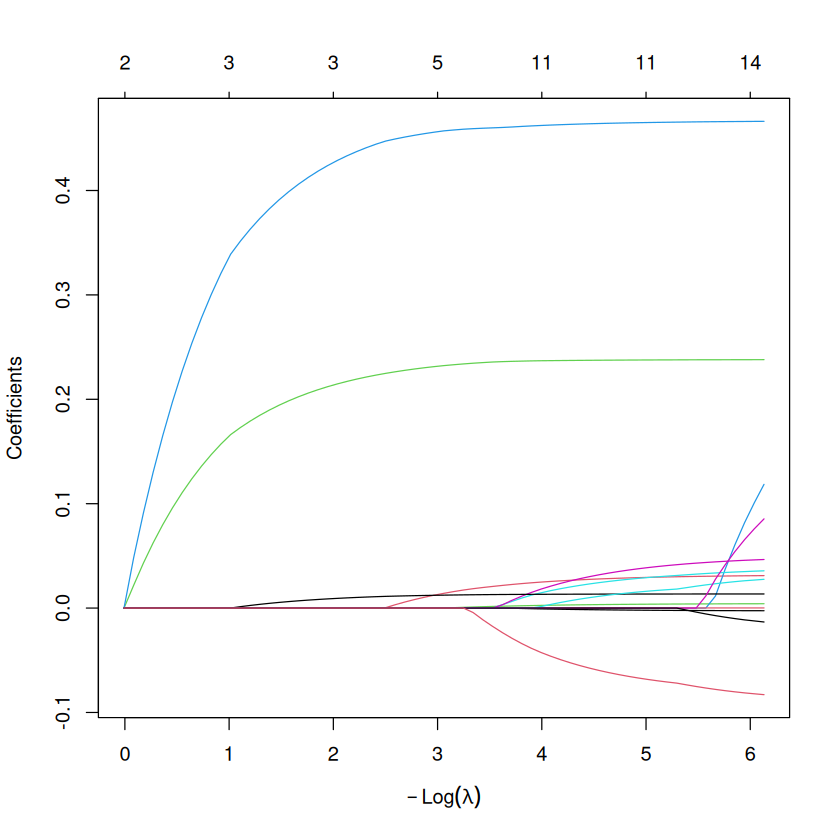

In [42]:

data_model <- df_clean %>%
  select(
    success_score,
    Price, `Required age`, `DLC count`,
    nb_languages, Windows, Mac, Linux,
    `Metacritic score`, Achievements,
    log_median_playtime, log_peak_ccu,
    has_website, has_screenshots,
    `has_support url`, `has_support email`
  ) %>%
  mutate(across(where(is.logical), as.numeric)) %>%
  drop_na()

X <- data.matrix(data_model %>% select(-success_score))
y <- data_model$success_score
set.seed(42)

lasso_cv <- cv.glmnet(
  X, y,
  alpha = 1,        # LASSO
  standardize = TRUE
)

set.seed(42)

lasso_cv <- cv.glmnet(
  X, y,
  alpha = 1,
  standardize = TRUE
)

plot(lasso_cv$glmnet.fit, xvar = "lambda")

coef_lasso <- coef(lasso_cv, s = "lambda.min")


important_vars <- as.matrix(important_vars)
important_vars <- important_vars[order(abs(important_vars[,1]), decreasing = TRUE), ]
important_vars